**Notebook for the paper**<br/>
**_A churn prediction dataset from the telecom sector: a new benchmark for uplift modeling_**<br/>
_Anonymous authors_
# Benchmark for uplift models on the churn dataset

In [2]:
%load_ext autoreload
%autoreload 2
import pickle
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import normalize
from os.path import join
from scipy.stats import entropy

from functions.wrappers import URFCWrapper, RandomForestWrapper, SLearnerWrapper
from functions.benchmark import benchmark
from functions.dataset import Dataset
from functions.easy_ensemble import EasyEnsemble
from functions.eval_measures import uplift_curve, calibrate_score
from statsmodels.stats.proportion import proportions_ztest

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data preparation

In [3]:
data = pd.read_csv("churn_uplift_anonymized.csv")

In [4]:
exclude_from_X = [
    'y',
    't'
]
columns_X = [c for c in data.columns if c not in exclude_from_X]
dataset = Dataset(
    X = data[columns_X],
    y = data.y == 1,
    t = data.t == 1
)

In [5]:
def replace_less_common(df, k=10, replacement="Other"):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype in ["string", "object", "category"]:
            top_values = df[col].value_counts()[:k]
            df.loc[~df[col].isin(top_values.index), col] = replacement
    return df

In [6]:
# Factor encoding
dataset.X = replace_less_common(dataset.X)
dataset.X = pd.get_dummies(dataset.X).to_numpy().astype("float32")
dataset.X[~np.isfinite(dataset.X)] = 0

# Data normalization
dataset.X = dataset.X[:, dataset.X.std(axis=0) != 0]
normalization = "minmax"
if normalization == "gaussian":
    m = dataset.X.mean(axis=0)
    s = dataset.X.std(axis=0)
    dataset.X = (dataset.X - m) / s
elif normalization == "minmax":
    M = dataset.X.max(axis=0)
    m = dataset.X.min(axis=0)
    dataset.X = (dataset.X - m) / (M - m)

# Target variables
dataset.t = np.array(dataset.t)
dataset.y = np.array(dataset.y)

In [7]:
y_0 = dataset.y[~dataset.t]
y_1 = dataset.y[dataset.t]
U = y_0.mean() - y_1.mean()
stat, pval = proportions_ztest(np.array([y_0.sum(), y_1.sum()]), np.array([y_0.shape[0], y_1.shape[0]]))
print("pval = {:.1%}\t(U = {:.2%}, z = {})".format(pval, U, stat))

pval = 47.9%	(U = 0.28%, z = 0.7072974933747597)


In [8]:
print("S_0 = {:.2%}".format(y_0.mean()))
print("S_1 = {:.2%}".format(y_1.mean()))
print("Uplift in this dataset: {:.2%}".format(U))

S_0 = 3.64%
S_1 = 3.36%
Uplift in this dataset: 0.28%


In [9]:
with open("../data/prepared_churn_dataset.pickle", 'wb') as f:
    pickle.dump(dataset, f)

### Benchmark setup

In [10]:
with open("../data/prepared_churn_dataset.pickle", "rb") as f:
    dataset = pickle.load(f)

In [11]:
seed = None

In [12]:
import glob

hits = []
for p in glob.glob("functions/**/*.py", recursive=True):
      with open(p, "r", encoding="utf-8", errors="ignore") as f:
          if "class XClassifierWrapper" in f.read():
              hits.append(p)

hits

[]

In [13]:
# from functions.wrappers import (
#     URFCWrapper, RandomForestWrapper, SLearnerWrapper,
#     XClassifierWrapper, CEVAEWrapper
# )

# # import RFeature from whichever module contains it
# from functions.rfeature import RFeature  # change filename if needed

In [14]:
from math import sqrt
from sklearn.ensemble import RandomForestClassifier
from functions.wrappers import URFCWrapper, RandomForestWrapper, SLearnerWrapper
from functions.easy_ensemble import EasyEnsemble

seed = None

models = {}
max_features = int(sqrt(dataset.X.shape[1]))
n_estimators = 100
max_depth = 20
min_samples_leaf = 10
n_folds = 8

# Uplift random forest (causalml) + EasyEnsemble
models["urf"] = EasyEnsemble(
    URFCWrapper(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_treatment=min_samples_leaf,
        max_features=max_features,
        n_jobs=1,
        random_state=seed
    ),
    n_folds=n_folds,
    n_jobs=-1,
    random_state=seed,
    verbose=False
)

# Churn risk (control-only) + EasyEnsemble
models["rf"] = EasyEnsemble(
    RandomForestWrapper(
        n_jobs=1,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=seed
    ),
    n_folds=n_folds,
    n_jobs=-1,
    random_state=seed,
    verbose=False
)

# S-learner + EasyEnsemble
models["rf_slearner"] = EasyEnsemble(
    SLearnerWrapper(
        n_jobs=1,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=seed
    ),
    n_folds=n_folds,
    n_jobs=-1,
    random_state=seed,
    verbose=False
)

models_to_run = ["rf", "rf_slearner", "urf"]
models = {name: models[name] for name in models_to_run}

In [24]:
results_file = "prepared_churn_dataset.pickle"

In [25]:
n_repeats = 10
k_folds = 3

### Benchmark

In [26]:
print("X shape:", dataset.X.shape)
print("Models:", list(models.keys()))
print("k_folds:", k_folds, "n_repeats:", n_repeats, "n_folds (EasyEnsemble):", n_folds)
print("Approx URF fits:", k_folds * n_repeats * n_folds)
print("Approx URF trees:", k_folds * n_repeats * n_folds * n_estimators)

X shape: (11896, 284)
Models: ['rf', 'rf_slearner', 'urf']
k_folds: 3 n_repeats: 10 n_folds (EasyEnsemble): 8
Approx URF fits: 240
Approx URF trees: 24000


In [27]:
import pandas as pd

In [28]:
results = benchmark(
    dataset,
    models=models,
    k_folds=k_folds,
    n_repeats=n_repeats,
    seed=None,
    verbose=False,
    predict_params={
        "urf": {"full_output": True}
    }
)
if True:
    with open(results_file, 'wb') as f:
        pickle.dump(results, f)

  0%|          | 0/30 [00:00<?, ?it/s]

In [29]:
with open(results_file, "rb") as f:
    results = pickle.load(f)

### Estimating the mutual information and the estimator variance

First, build the array of predictions of each model, to compute the variance

In [ ]:
preds = {}
for model_name in models:
    all_pred = np.empty((dataset.X.shape[0], n_repeats))
    for i, split in enumerate(results):
        i_repeat = i // k_folds
        pred = split["results"][model_name]["pred"]
        if model_name.startswith("urf") or model_name == "rf_slearner":
            pred = pred["control"] - pred["target"]
        elif model_name == "xlearner":
            pred = pred[:,0]
        all_pred[split["test_indices"], i_repeat] = pred
    all_pred[np.isnan(all_pred)] = 0
    all_pred[all_pred > 1e10] = 0 # handle overflow
    preds[model_name] = all_pred

In [31]:
def estimator_variance(preds):
    preds[preds <= -1] = -1
    preds[preds >= 1] = 1
    preds[np.isnan(preds)] = 0
    return np.mean(np.var(preds, axis=1))

In [32]:
variances = {model_name: estimator_variance(preds[model_name]) for model_name in models}

In [35]:
print("Var_u = {:.2%}".format(variances["urf"]))
print("Var_p = {:.2%}".format(variances["rf"]))
#print("Var_x = {:.2%}".format(variances["xlearner"]))
print("Var_s = {:.2e}".format(variances["rf_slearner"]))

Var_u = 0.25%
Var_p = 0.20%
Var_s = 4.03e-03


Then, estimate the individual counterfactual probabilities to estimate the mutual information

In [36]:
S_0_prior = np.mean(dataset.y[~dataset.t])
S_1_prior = np.mean(dataset.y[dataset.t])

In [37]:
S_0 = np.empty((dataset.X.shape[0], n_repeats))
S_1 = np.empty((dataset.X.shape[0], n_repeats))

for i, split in enumerate(results):
    i_repeat = i // k_folds
    S_0_split = split["results"]["rf_slearner"]["pred"]["control"]
    S_1_split = split["results"]["rf_slearner"]["pred"]["target"]
    #S_0_split = calibrate_score(S_0_split, S_0_prior)
    #S_1_split = calibrate_score(S_1_split, S_1_prior)
    S_0[split["test_indices"], i_repeat] = S_0_split
    S_1[split["test_indices"], i_repeat] = S_1_split

S_0[np.isnan(S_0)] = 0
S_1[np.isnan(S_1)] = 0
S_0[S_0 >= 1] = 1
S_1[S_1 >= 1] = 1
S_0[S_0 <= 0] = 0
S_1[S_1 <= 0] = 0
S_0 = np.mean(S_0, axis=1)
S_1 = np.mean(S_1, axis=1)

In [38]:
# Calibrate two times for more precision
S_0 = calibrate_score(calibrate_score(S_0, S_0_prior), S_0_prior)
S_1 = calibrate_score(calibrate_score(S_1, S_1_prior), S_1_prior)

In [39]:
def counterfactuals(S_0_x, S_1_x):
    alpha_x = (1 - S_0_x) * (1 - S_1_x)
    beta_x = S_0_x * (1 - S_1_x)
    gamma_x = (1 - S_0_x) * S_1_x
    delta_x = S_0_x * S_1_x
    alpha = np.mean(alpha_x)
    beta = np.mean(beta_x)
    gamma = np.mean(gamma_x)
    delta = np.mean(delta_x)
    return (alpha, beta, gamma, delta)

def mutual_information_marginal(S_x, S):
    return entropy([S, 1 - S]), np.mean(entropy(np.vstack((S_x, 1 - S_x))))

In [40]:
alpha, beta, gamma, delta = counterfactuals(S_0, S_1)
print("alpha = {:.1%}".format(alpha))
print("beta  = {:.1%}".format(beta))
print("gamma = {:.1%}".format(gamma))
print("delta = {:.1%}".format(delta))

alpha = 93.1%
beta  = 3.5%
gamma = 3.2%
delta = 0.1%


In [41]:
H_Y_0, H_Y_0_X = mutual_information_marginal(S_0, S_0_prior)
H_Y_1, H_Y_1_X = mutual_information_marginal(S_1, S_1_prior)

In [42]:
print(S_0_prior)
print(S_1_prior)

0.036382536382536385
0.03362930077691454


In [43]:
print("I_0 = {:.2%}".format(1 - H_Y_0_X / H_Y_0))
print("I_1 = {:.2%}".format(1 - H_Y_1_X / H_Y_1))

I_0 = 0.34%
I_1 = 0.94%


### Plotting uplift curves

In [44]:
curves = {}
auucs = {}

S_0_prior = np.mean(dataset.y[~dataset.t])
S_1_prior = np.mean(dataset.y[dataset.t])
auucs["random"] = (S_0_prior - S_1_prior) / 2
N = dataset.X.shape[0]

for model_name in models:
    curves[model_name] = []
    auucs[model_name] = []
    for i, split in enumerate(results):
        i_repeat = i // k_folds
        pred = split["results"][model_name]["pred"]
        if model_name.startswith("urf") or model_name == "rf_slearner":
            pred = pred["control"] - pred["target"]
        elif model_name == "xlearner":
            pred = pred[:,0]
        if model_name in ("cevae", "xlearner", "xlearner_rfeature", "rf_slearner"):
            pred = -pred
        pred[np.isnan(pred)] = 0
        pred[pred > 1e10] = 0 # Sometimes some models give huge scores
        curve = uplift_curve(dataset.y[split["test_indices"]], dataset.t[split["test_indices"]], pred)
        curves[model_name].append(curve)
        auucs[model_name].append(curve.profit.mean() / len(split["test_indices"]))

In [47]:
print("AUUC_u = {:.2%}".format(np.mean(auucs["urf"])))
print("AUUC_p = {:.2%}".format(np.mean(auucs["rf"])))
#print("AUUC_x = {:.2%}".format(np.mean(auucs["xlearner"])))
print("AUUC_s = {:.2%}".format(np.mean(auucs["rf_slearner"])))

AUUC_u = 0.09%
AUUC_p = 0.25%
AUUC_s = 0.20%


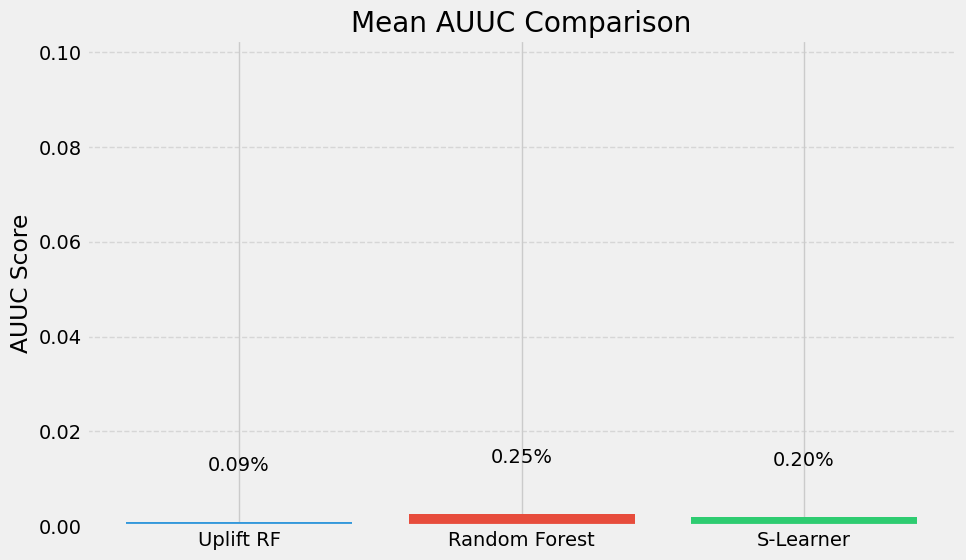

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Uplift RF', 'Random Forest', 'S-Learner']
values = [
    np.mean(auucs["urf"]), 
    np.mean(auucs["rf"]), 
    np.mean(auucs["rf_slearner"])
]

# 2. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#3498db', '#e74c3c', '#2ecc71'])

# 3. Add the percentage labels on top of the bars (mimicking your print output)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, '{:.2%}'.format(yval), ha='center', va='bottom')

plt.title('Mean AUUC Comparison')
plt.ylabel('AUUC Score')
plt.ylim(0, max(values) + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()